In [57]:
%load_ext autoreload
%autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [58]:
%reload_ext autoreload

In [59]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import tqdm
from time import time_ns

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 8
print(f"Currently using {DEVICE}")

Currently using cuda


In [60]:
%autoreload

In [61]:
from src.data_import import *
train_loader, test_loader = load_fashion_mnist(batch_size=BATCH_SIZE, shuffle=True, class_subset=[9])

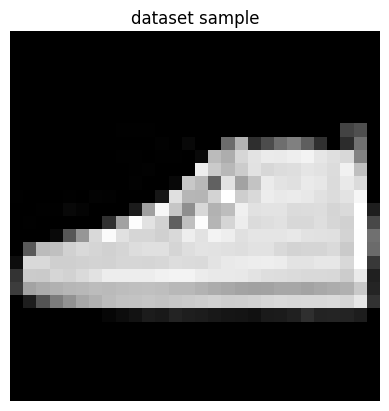

label: 9
shape: torch.Size([8, 1, 28, 28])


In [62]:
from src.plot import show_single_sample, show_grid

x_real, _ = next(iter(train_loader))
show_single_sample(x_real[0], "dataset sample", cmap="gray")
#print label
print("label:", _[0].item())
print("shape:", x_real.shape)

In [63]:
n_heads = 3
IMAGE_SHAPE = (1, 28, 28)

In [64]:
from src.model import EBM

model = EBM(image_shape=IMAGE_SHAPE, n_heads=n_heads, batch_size=BATCH_SIZE)
for head in model.heads:
    head.to(DEVICE)

model.to(DEVICE)

EBM(
  (heads): ModuleList(
    (0-2): 3 x EnergyHead(
      (conv): Sequential(
        (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): GELU(approximate='none')
        (2): Conv2d(16, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
        (3): GELU(approximate='none')
        (4): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
        (5): GELU(approximate='none')
      )
      (fc): Sequential(
        (0): Linear(in_features=3136, out_features=49, bias=True)
        (1): GELU(approximate='none')
        (2): Linear(in_features=49, out_features=1, bias=True)
      )
    )
  )
)

In [65]:
from src.sampler import ReplaySampler

sampler = ReplaySampler(model, img_shape=IMAGE_SHAPE, buffer_size=600, noise_fraction=0.05, device=DEVICE)

In [66]:
from src.information import TotalCorrelationEstimator

total_correlation_estimator = TotalCorrelationEstimator(n_heads, hidden_dim=16, lr=1e-3)
total_correlation_estimator.to(DEVICE)

In [67]:
from src.train import train_one_epoch_TC, train_one_epoch
#torch.autograd.set_detect_anomaly(True, check_nan=False)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, betas=(0.000, 0.999))

for epoch in range(8):
    epoch_loss, _ = train_one_epoch_TC(
        model, 
        sampler, 
        train_loader, 
        optimizer,

        sample_steps=50,
        sample_step_size=10.0,
        sample_noise_std=0.005,
        energy_reg=1e-1,
        tc_regularizations=1e-2,
        
        tc_estimator=total_correlation_estimator,
        device=DEVICE
    )
    print(f"Epoch {epoch+1}, Loss: {epoch_loss:.4f}")

    if epoch % 5 == 0:
        pass # torch.save(model.state_dict(), f"./models/lfw/EBM_{epoch}_epochs_{len(model.heads)}_heads_{IMAGE_SHAPE}_shape_{time_ns()}t.pth")


100%|██████████| 750/750 [03:37<00:00,  3.45it/s]


Epoch 1, Loss: 0.0051


100%|██████████| 750/750 [03:39<00:00,  3.42it/s]


Epoch 2, Loss: 0.8660


100%|██████████| 750/750 [03:32<00:00,  3.53it/s]


...

Epoch 6, Loss: 10.6297


100%|██████████| 750/750 [03:38<00:00,  3.44it/s]


Epoch 7, Loss: 14.0239


100%|██████████| 750/750 [03:33<00:00,  3.50it/s]

Epoch 8, Loss: 17.7477


EBM DIAGNOSTICS

[1] Energy on real data
  Train  →  mean=-0.0164,  std=0.0406
  Test   →  mean=-0.0162,  std=0.0469
  |E_test - E_train| = 0.0003  (ok)

[2] Energy on fake data (Langevin samples)
  Fake   →  mean=-0.0224,  std=0.0318
  Gap (E_real_train - E_fake) = 0.0059  (WARNING: gap inverted)

[3] Energy on pure noise
  Noise  →  mean=2.2466,  std=0.0438
  Gap (E_real_train - E_noise) = -2.2630  (ok)

[4] Per-head energy (on train batch)
  Head 0  →  mean=-0.1588,  std=0.0117
  Head 1  →  mean=0.2527,  std=0.0107
  Head 2  →  mean=-0.1135,  std=0.0294
  Max off-diagonal correlation: 0.9542  (WARNING: heads are correlated)

[5] Replay buffer
  Buffer size: 600 / 600
  Buffer samples  →  mean=-0.4081,  std=0.7179,  min=-1.0000,  max=1.0000

[6] Visual samples (Langevin from noise)


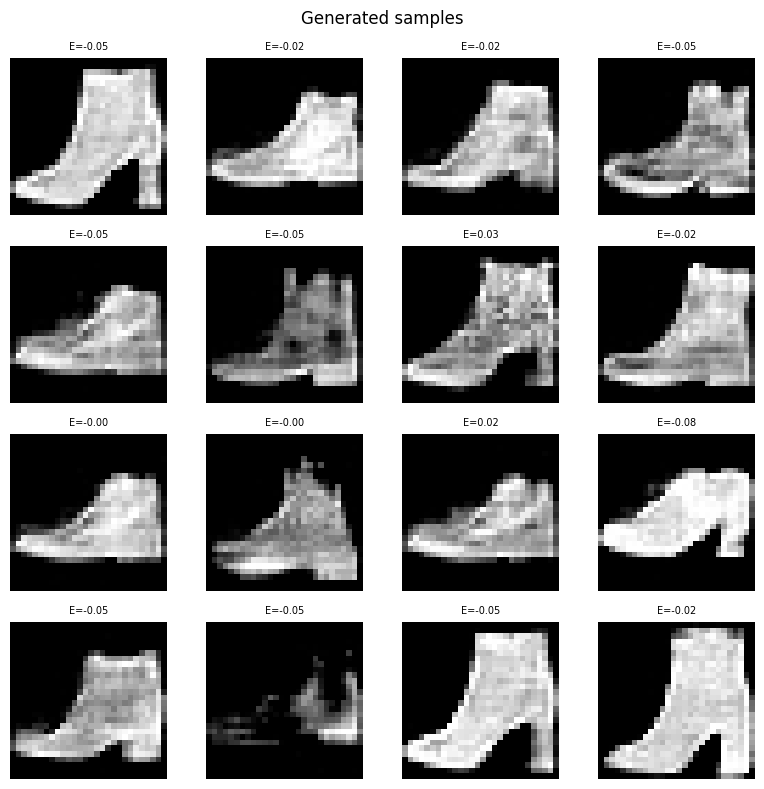


DONE


In [68]:
from src.diagnostic import diagnose

diagnose(model, sampler, IMAGE_SHAPE, train_loader, test_loader, device=DEVICE, n_samples=16)

In [69]:
model.to(DEVICE)

EBM(
  (heads): ModuleList(
    (0-2): 3 x EnergyHead(
      (conv): Sequential(
        (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): GELU(approximate='none')
        (2): Conv2d(16, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
        (3): GELU(approximate='none')
        (4): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
        (5): GELU(approximate='none')
      )
      (fc): Sequential(
        (0): Linear(in_features=3136, out_features=49, bias=True)
        (1): GELU(approximate='none')
        (2): Linear(in_features=49, out_features=1, bias=True)
      )
    )
  )
)

In [70]:
model.to(DEVICE)
samples = sampler.generate(10, steps=600, step_size=10.0, noise_std=0.005)

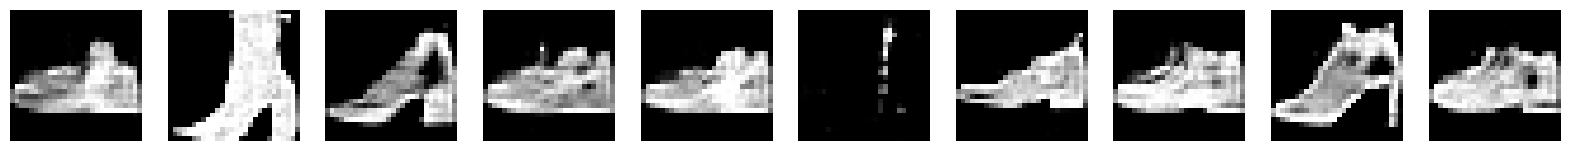

In [71]:
show_grid(samples, 10, cmap="gray")

In [72]:
# from src.plot import visualize_heads

# model.to("cpu")

# fig = visualize_heads(
#     model, 
#     steps=200, 
#     step_size=10.0, 
#     noise_std=0.01,
#     k=3,
#     cmap="Grays",
# )

# model.to(DEVICE)

In [73]:
# model = EBM(image_shape=(1,64,64), n_heads=3)
# mn = "EBM_20_epochs_(1, 64, 64)_shape_3_heads_1782902908565130435"
# f = "./models/olivetti/" + mn + ".pth"
# model.load_state_dict(torch.load(f))

In [74]:
from src.plot import visualize_head_gradients, visualize_head_abs_gradients

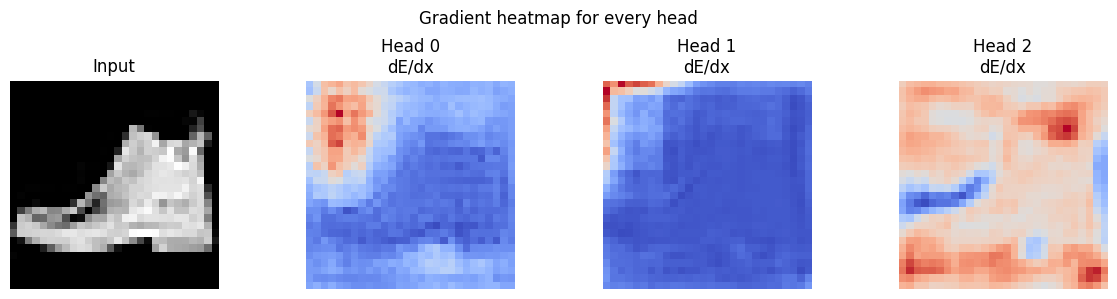

In [75]:
it = iter(test_loader)

for _ in range(6):
    it.__next__()
x0 = it.__next__()[0]

visualize_head_gradients(model.to(DEVICE), x0, DEVICE)


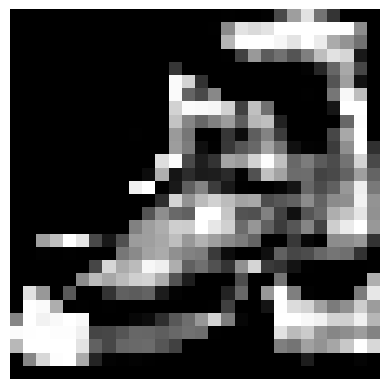

In [ ]:
from src.gradient_inspect import synthetize_image_from_head, synthetize_image

class Combined(nn.Module):
    def __init__(self, m1, m2=None):
        super().__init__()
        self.m1 = m1
        self.m2 = m2
    def forward(self, x):
        if self.m2 is None:
            return self.m1(x)
        return self.m1(x) + self.m2(x)

combined = Combined(model.heads[1].to("cpu"), model.heads[0].to("cpu"))

img, _ = synthetize_image_from_head(combined, n_images=1, img_dimension=IMAGE_SHAPE[-1], steps=1_000)
show_single_sample(img, cmap="gray")


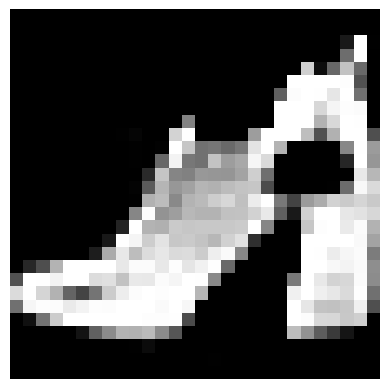

In [77]:
img, _ = synthetize_image(model.to("cpu"), img_dimension=IMAGE_SHAPE[-1], steps=1_000)
show_single_sample(img, cmap="gray")

In [78]:
torch.save(model.state_dict(), f"./models/EBM_{epoch}_epochs_{len(model.heads)}_heads_{IMAGE_SHAPE}_shape_{time_ns()}t.pth")